# Google Cluster Trace Dataset Analysis - Google Storage

In [1]:
import os
import pandas as pd
import subprocess
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.mixture import GaussianMixture
import numpy as np
import scipy.stats as stats

## Download the data files

Here we download the JSON files from the google cloud storage.
The instructions can be found in [Google cluster data usage trace documentation](https://drive.google.com/file/d/10r6cnJ5cJ89fPWCgj7j4LtLBqYN9RiI9/view).

It should be noted that all the files are several TB large, and thus it is better to just download one or few files and inspect them to sample random jobs and their characteristics.

Here we download instance usage and machine events.

In [2]:
def download_json(gcs_path, local_dir="data"):
    """Downloads JSON files from Google Cloud Storage."""
    if not os.path.exists(local_dir):
        os.makedirs(local_dir)

    print(f"Downloading: {gcs_path}")
    subprocess.run(["gsutil", "cp", gcs_path, local_dir], check=True)

In [3]:
INSTANCE_USAGE_JSON_GS_PATH = "gs://clusterdata_2019_a/instance_usage-000000000000.json.gz"
MACHINE_EVENTS_JSON_GS_PATH = "gs://clusterdata_2019_a/machine_events-000000000000.json.gz"
COLLECTION_EVENTS_JSON_GS_PATH = "gs://clusterdata_2019_a/collection_events-000000000000.json.gz"

INSTANCE_USAGE_JSON_PATH = "data/instance_usage-000000000000.json.gz"
MACHINE_EVENTS_JSON_PATH = "data/machine_events-000000000000.json.gz"
COLLECTION_EVENTS_JSON_PATH = "data/collection_events-000000000000.json.gz"

N = 100_000

In [4]:
download_json(INSTANCE_USAGE_JSON_GS_PATH)

Downloading: gs://clusterdata_2019_a/instance_usage-000000000000.json.gz


In [5]:
download_json(MACHINE_EVENTS_JSON_GS_PATH)

Downloading: gs://clusterdata_2019_a/machine_events-000000000000.json.gz


In [6]:
download_json(COLLECTION_EVENTS_JSON_GS_PATH)

Downloading: gs://clusterdata_2019_a/collection_events-000000000000.json.gz


In [7]:
!gzip -l $INSTANCE_USAGE_JSON_PATH # 500mb compressed, 4 GB uncompressed

         compressed        uncompressed  ratio uncompressed_name
          498371634          3999791677  87.5% data/instance_usage-000000000000.json


In [8]:
!gzip -cd $INSTANCE_USAGE_JSON_PATH | head

{"start_time":"1838400000000","end_time":"1838700000000","collection_id":"330587238433","instance_index":"111","machine_id":"23624491139","alloc_collection_id":"330587160469","alloc_instance_index":"111","collection_type":"0","average_usage":{"cpus":0.008392333984375,"memory":0.0094757080078125},"maximum_usage":{"cpus":0.04791259765625,"memory":0.019378662109375},"random_sample_usage":{"cpus":0.016632080078125},"assigned_memory":0,"page_cache_memory":0.0032196044921875,"cycles_per_instruction":0.89924430847167969,"memory_accesses_per_instruction":0.00151212012860924,"sample_rate":0.996666669845581,"cpu_usage_distribution":[0.0004711151123046875,0.0006809234619140625,0.00075817108154296875,0.00083160400390625,0.00096225738525390625,0.0084381103515625,0.008880615234375,0.0133056640625,0.016448974609375,0.021942138671875,0.04779052734375],"tail_cpu_usage_distribution":[0.022308349609375,0.023681640625,0.024200439453125,0.025360107421875,0.02606201171875,0.02685546875,0.028411865234375,0.0

## Cleaning data

Here we load the data files and clean them. Since even the downloaded `json.gz` files can be several GB large, we only load first N rows.

The start and end times have to be converted to seconds since the document mentions that the timestamps in micro-seconds only for consistency (but the precision is actually seconds).

Furthermore, tasks before `600` seconds are tasks that started before data collection period, so we can remove them. Additionally, since we only consider 7 days data, we remove all the tasks started after 7 days.

Furthermore, there are some rows with N/A values, we have to remove them.

In [9]:
df_iu = pd.read_json(INSTANCE_USAGE_JSON_PATH, lines=True, nrows=N, convert_dates=False)

In [10]:
df_me = pd.read_json(MACHINE_EVENTS_JSON_PATH, lines=True, nrows=N, convert_dates=False)

In [11]:
df_ce = pd.read_json(COLLECTION_EVENTS_JSON_PATH, lines=True, nrows=N, convert_dates=False)

In [12]:
df_iu["start_time"] = df_iu["start_time"].apply(lambda x: x // 1_000_000)
df_iu["end_time"] = df_iu["end_time"].apply(lambda x: x // 1_000_000)

In [13]:
df_iu = df_iu[(df_iu["start_time"] >= 600) & (df_iu["start_time"] < 600 + 86400 * 7)]  # Tasks before/after cut-off
df_iu = df_iu[df_iu["end_time"] - df_iu["start_time"] < 300]  # Tasks that exceeded measurement time

In [14]:
df_me = df_me.dropna()

In [15]:
df_iu.head()

,start_time,end_time,collection_id,instance_index,machine_id,alloc_collection_id,alloc_instance_index,collection_type,average_usage,maximum_usage,random_sample_usage,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution
74,104400,104461,330587238433,1315,21382998,330587160469,1315,0,"{'cpus': 0.01800537109375, 'memory': 0.0133666...","{'cpus': 0.02301025390625, 'memory': 0.0134735...",{'cpus': 0.019073486328125},0,0.002480,1.069491,0.001977,1.0,"[0.011260986328125002, 0.01312255859375, 0.014...","[0.02264404296875, 0.022705078125, 0.022735595..."
75,104461,104663,330587238433,1315,21382998,330587160469,1315,0,"{'cpus': 0.012588500976562, 'memory': 0.009414...","{'cpus': 0.022857666015625003, 'memory': 0.013...",{'cpus': 0.0007543563842770001},0,0.002430,0.970140,0.001563,1.0,"[2.9563903808593753e-05, 0.0002651214599600000...","[0.02166748046875, 0.021728515625, 0.021820068..."
78,97200,97397,330587238433,1315,21382998,330587160469,1315,0,"{'cpus': 0.009780883789062, 'memory': 0.009490...","{'cpus': 0.022979736328125003, 'memory': 0.018...",{'cpus': 0.019378662109375},0,0.001064,1.305863,0.002810,1.0,"[6.67572021484375e-05, 0.0006437301635740001, ...","[0.0181884765625, 0.018463134765625, 0.0197753..."
79,97397,97400,330587238433,1315,21382998,330587160469,1315,0,"{'cpus': 0.013824462890625002, 'memory': 0.015...","{'cpus': 0.025787353515625003, 'memory': 0.018...",{'cpus': 0.015625},0,0.000587,1.305863,0.002810,1.0,"[0.006301879882812, 0.006301879882812, 0.00630...","[0.015121459960937, 0.015121459960937, 0.01512..."
92,101100,101363,330587238433,1315,21382998,330587160469,1315,0,"{'cpus': 0.019287109375, 'memory': 0.018493652...","{'cpus': 0.03717041015625, 'memory': 0.0191345...",{'cpus': 0.019195556640625},0,0.000297,1.046010,0.001827,1.0,"[0.013198852539062, 0.01641845703125, 0.017242...","[0.0225830078125, 0.02264404296875, 0.02273559..."


In [16]:
df_me.head()

,time,machine_id,type,switch_id,platform_id,capacity
459,0,92126449465,1,+EyjgSS2LwdyWwDxptBhRO8AYKyTwW+ibYUeOF46XRA=,Dza/U2s43vvYOOFCmkikwthqRcXXkIyR/WG6M23f67s=,"{'cpus': 1, 'memory': 0.5}"
460,1115701818978,92126449465,1,+EyjgSS2LwdyWwDxptBhRO8AYKyTwW+ibYUeOF46XRA=,Dza/U2s43vvYOOFCmkikwthqRcXXkIyR/WG6M23f67s=,"{'cpus': 1, 'memory': 0.5}"
461,0,92065249319,1,+EyjgSS2LwdyWwDxptBhRO8AYKyTwW+ibYUeOF46XRA=,Dza/U2s43vvYOOFCmkikwthqRcXXkIyR/WG6M23f67s=,"{'cpus': 1, 'memory': 0.5}"
462,1040224094227,92065249319,1,+EyjgSS2LwdyWwDxptBhRO8AYKyTwW+ibYUeOF46XRA=,Dza/U2s43vvYOOFCmkikwthqRcXXkIyR/WG6M23f67s=,"{'cpus': 1, 'memory': 0.5}"
463,0,92046587157,1,+EyjgSS2LwdyWwDxptBhRO8AYKyTwW+ibYUeOF46XRA=,Dza/U2s43vvYOOFCmkikwthqRcXXkIyR/WG6M23f67s=,"{'cpus': 1, 'memory': 0.5}"


In [17]:
df_ce.head()

,time,type,collection_id,scheduling_class,collection_type,priority,user,collection_name,collection_logical_name,start_after_collection_ids,vertical_scaling,scheduler,parent_collection_id,missing_type,max_per_machine,max_per_switch,alloc_collection_id
0,2181847986340,5,396233419682,1,0,103,/o4X3IunK+hhQOPr+NRkjWgxjdJlGtk9ujTmgsSlZKc=,uPV3/TgB5WMfJTzMEzf3tJaHuDqfgiSXFbBVl2UYWb8=,KJ8MV0Juy9uRXkIXxeA23iH+VVSuQ9++X+zRcNfUsEg=,[],2.0,1.0,NaN,NaN,NaN,NaN,NaN
1,1685777786697,5,385607584057,3,0,0,RafrUOPLtxAkG9IUoVaF8YjjXcVPt1EnEP6Zn+cQ/ko=,os7lm8wNvvr9P9qkeuA8zQY5bosEiARvh1UbtivIYG8=,bA/e9j8XWFimoE+RPjLjIgNOKj0m24eFDSE8fjQL6Ho=,[],1.0,0.0,NaN,NaN,NaN,NaN,NaN
2,65326129736,5,374545742577,2,0,115,12boQYioSPNeQSIhS/xwdE0K9pZ8Dqtfyr5X2MtxmZQ=,hiKHkc1co2UVp0OV41U2Tz3UsJIzV/ZlLBE5k/abQ4k=,mg4mwEDKc+7KvBT0lgyKDKjS8u4O75FVf32/ETjywp8=,[],1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,1423212472712,5,384593615712,3,0,0,RafrUOPLtxAkG9IUoVaF8YjjXcVPt1EnEP6Zn+cQ/ko=,os7lm8wNvvr9P9qkeuA8zQY5bosEiARvh1UbtivIYG8=,bA/e9j8XWFimoE+RPjLjIgNOKj0m24eFDSE8fjQL6Ho=,[],1.0,0.0,NaN,NaN,NaN,NaN,NaN
4,669667714997,5,381064289346,2,0,115,12boQYioSPNeQSIhS/xwdE0K9pZ8Dqtfyr5X2MtxmZQ=,MoEtfRGgVrMU+I4/dOJU0lKegB3rIASUJ9evipz6Wn8=,w1Nani0WSj1xOqnvG8CuqVXorPHhlMQkHXgQYp8FZK0=,[],2.0,1.0,NaN,NaN,NaN,NaN,NaN


## Generating Host stats

Host stats can be generated via SPEC dataset.

## Generating VM speeds

In [18]:
norm_cpu_speeds = df_me["capacity"].dropna().apply(lambda x: x["cpus"])
assumed_max_vm_speed_mips = 3 * 1024  # 3 GHz

cpu_speeds = norm_cpu_speeds * assumed_max_vm_speed_mips
cpu_speed_counts = cpu_speeds.value_counts(normalize=True)

cpu_speed_counts.index = cpu_speed_counts.index.astype(int)
cpu_speed_counts = cpu_speed_counts.sort_index()

cpu_speed_counts

,proportion
capacity,
1188,0.170280
1473,0.000087
1818,0.385774
2178,0.209091
2946,0.020717
3072,0.214052


<Axes: xlabel='capacity'>

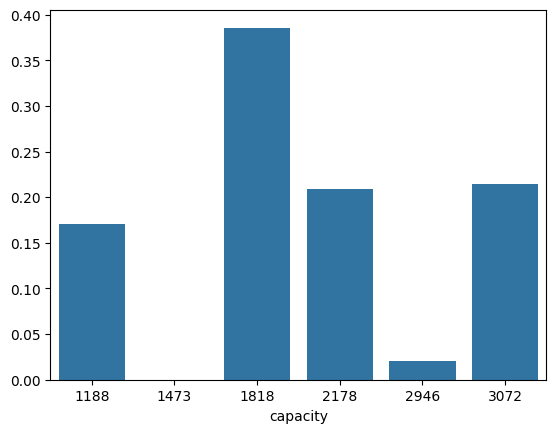

In [19]:
sns.barplot(x=cpu_speed_counts.index, y=cpu_speed_counts.values)

In [20]:
avg_vm_speed = cpu_speeds.mean()
avg_vm_speed

2077.755550699301

In [21]:
cpu_speed_counts.to_dict()

{1188: 0.17027972027972027,
 1473: 8.741258741258741e-05,
 1818: 0.3857736013986014,
 2178: 0.20909090909090908,
 2946: 0.020716783216783215,
 3072: 0.21405157342657344}

## Generating VM memory

In [22]:
norm_memory_capacities = df_me["capacity"].dropna().apply(lambda x: x["memory"])
assumed_max_vm_memory_capacity = 4 * 1024  # 4 GB

memory_capacities = norm_memory_capacities * assumed_max_vm_memory_capacity
memory_capacity_counts = memory_capacities.value_counts(normalize=True)

memory_capacity_counts.index = memory_capacity_counts.index.astype(int)
memory_capacity_counts = memory_capacity_counts.sort_index()

memory_capacity_counts

,proportion
capacity,
683,0.090406
1024,0.004371
1366,0.618029
2048,0.171941
2732,0.056643
4096,0.058610


<Axes: xlabel='capacity'>

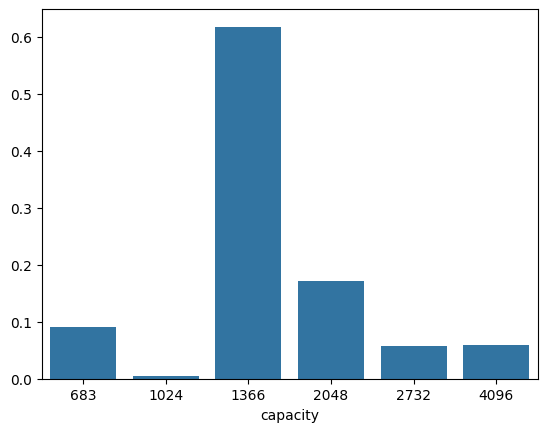

In [23]:
sns.barplot(x=memory_capacity_counts.index, y=memory_capacity_counts.values)

In [24]:
memory_capacity_counts.to_dict()

{683: 0.09040646853146853,
 1024: 0.004370629370629371,
 1366: 0.6180288461538461,
 2048: 0.17194055944055944,
 2732: 0.056643356643356645,
 4096: 0.05861013986013986}

## Generating VM disk

Let's assume there are 7 categories of disks. (1GB, 2GB, 5GB, 10GB, 15GB, 25GB, and 50GB) Let's assume these offerings are used in a normal distribution around 5GB.

<BarContainer object of 7 artists>

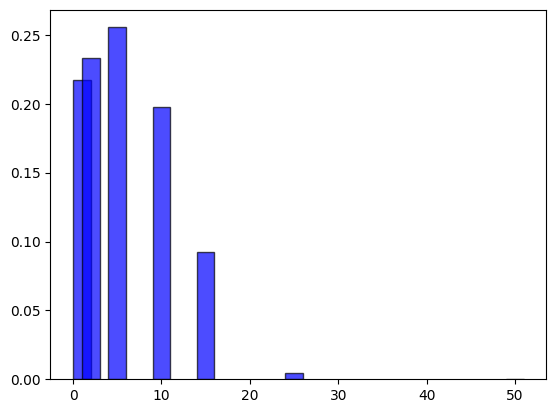

In [25]:
disk_sizes = np.array([1, 2, 5, 10, 15, 25, 50])
mean = 5  # Centered at 5GB
std_dev = 7  # Spread of the distribution
probabilities = stats.norm.pdf(disk_sizes, loc=mean, scale=std_dev)
probabilities /= probabilities.sum()

plt.bar(disk_sizes, probabilities, width=2, alpha=0.7, color="blue", edgecolor="black")

In [26]:
dict(zip(disk_sizes, probabilities))

{1: 0.2170190282340932,
 2: 0.23308742757720569,
 5: 0.2555071372084573,
 10: 0.1979764932559207,
 15: 0.09209698257774847,
 25: 0.004312930875267727,
 50: 2.713069602073165e-10}

## Generate task lengths

The machine specs are normalized, so it is not possible to infer the machine specs from machine events. So we have to assume a base speed. Assuming 1 GHz (1 unit).

```
GHz = MIPS / (IPC * 1000)
MIPS = (GHz * 1000) / CPI
```

Since we have the CPI of tasks, we can get the MIPS of VMs that ran them to get an assumed VM CPU speed.

```
Task Length = CPU usage * Exec Time * MIPS
```

Finally, we will scale the task lengths by multiplying it by a large number so they can be safely converted to integers.

[Text(0.5, 0, 'Task Lengths (MI)')]

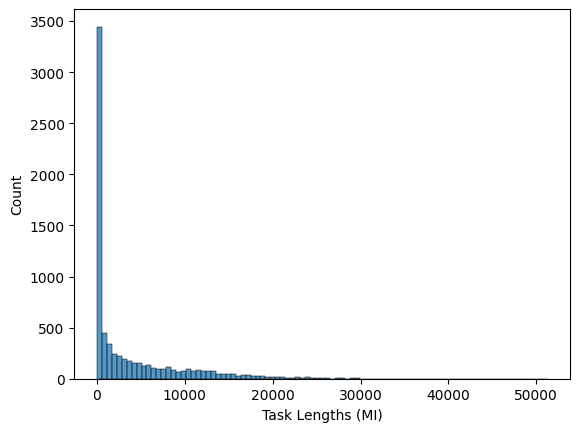

In [27]:
assumed_vm_cpu_speed_mips = avg_vm_speed / df_iu["cycles_per_instruction"]
cpu_usage = df_iu["average_usage"].apply(lambda x: x["cpus"])
execution_time = df_iu["end_time"] - df_iu["start_time"]
task_lengths = cpu_usage.values * execution_time.values * assumed_vm_cpu_speed_mips

ax = sns.histplot(x=task_lengths)
ax.set(xlabel="Task Lengths (MI)")

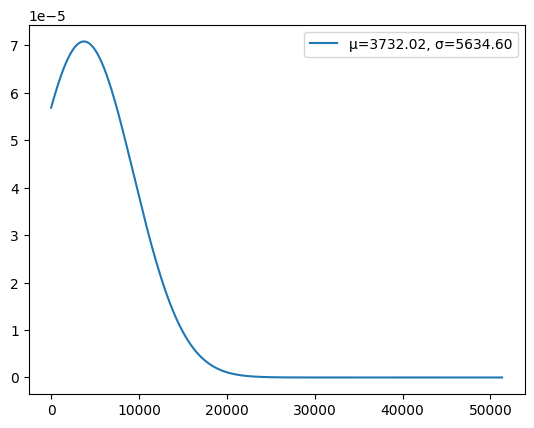

In [28]:
data = task_lengths.values
x = np.linspace(data.min(), data.max(), 1000)

gmm = GaussianMixture(n_components=1, random_state=42)
gmm.fit(data.reshape(-1, 1))

mean = gmm.means_.flatten()[0]
std = np.sqrt(gmm.covariances_).flatten()[0]
weight = gmm.weights_[0]

plt.plot(
    x,
    weight * (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2),
    label=f"μ={mean:.2f}, σ={std:.2f}",
)
plt.legend()
plt.show()

In [29]:
std

5634.604574122837

In [30]:
mean

3732.0194945492985

## Generating Task Priorities

In [31]:
priority_counts = df_ce["priority"].value_counts(normalize=True)

priority_counts.index = priority_counts.index.astype(int)
priority_counts = priority_counts.sort_index()

<Axes: xlabel='priority'>

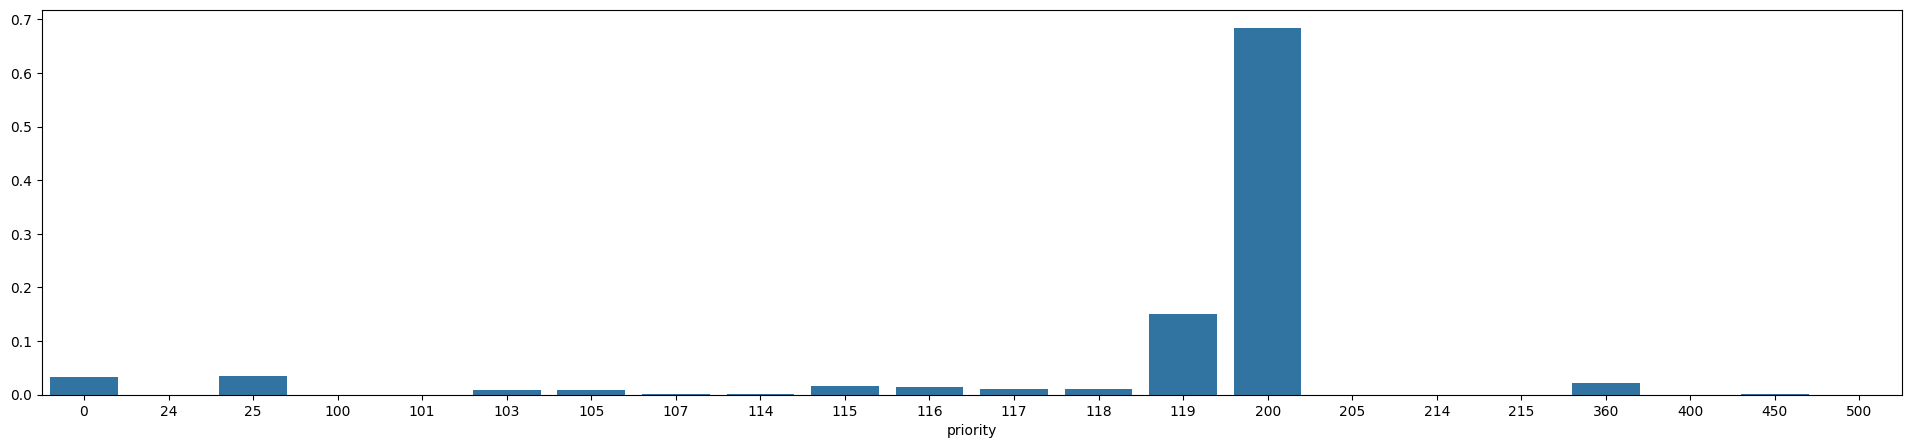

In [32]:
fig, ax = plt.subplots(figsize=(24, 5))
sns.barplot(x=priority_counts.index, y=priority_counts.values, ax=ax)

In [33]:
pv = df_ce["priority"].values
((pv >= 120) & (pv <= 300)).sum() / len(pv)

0.68388

In [34]:
priority_counts.to_dict()

{0: 0.03338,
 24: 2e-05,
 25: 0.03517,
 100: 0.00023,
 101: 0.00011,
 103: 0.00923,
 105: 0.00903,
 107: 0.00217,
 114: 0.00056,
 115: 0.01689,
 116: 0.01449,
 117: 0.01021,
 118: 0.01042,
 119: 0.15108,
 200: 0.68382,
 205: 4e-05,
 214: 1e-05,
 215: 1e-05,
 360: 0.02131,
 400: 1e-05,
 450: 0.0018,
 500: 1e-05}

## Generating Task Structure

Task structure can be generated from Pegasus Workflow Generator tool.
https://github.com/pegasus-isi/WorkflowGenerator/blob/master/bharathi/README